Sources
https://aboskovic21.github.io/projects/pu_gb.pdf
optuna

In [1]:


import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams['text.usetex'] = False

In [2]:
# Main code voor processen van de data
import uproot
import sklearn
import xgboost
import pathlib
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
from matplotlib.pyplot import figure
import corner

figure(figsize=(8, 6), dpi=80)

# Background
with uproot.open(pathlib.Path(r"C:\Users\apogo\Downloads\Data_Dpluspp7TeV_pT_2_3.root")) as file:
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_bkg = tree.arrays(branches, library="np")
    training_data_bkg['species'] = np.zeros(len(training_data_bkg['inv_mass']))
    # data_matrix = np.column_stack([data[b][:10000] for b in branches])

    # plt.figure(dpi=300)
    # fig = corner.corner(data_matrix, labels=branches)
    # inv_mass_training = tree.arrays(['inv_mass'],library='np')

# Signal
with uproot.open(pathlib.Path(r"C:\Users\apogo\Downloads\FD_Dpluspp7TeV_pT_2_3 (1).root")) as file:
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_FD = tree.arrays(branches, library="np")
    training_data_FD['species'] = np.ones(len(training_data_FD['inv_mass']))
    # data_matrix = np.column_stack([data[b][:10000] for b in branches])

    # plt.figure(dpi=300)
    # fig = corner.corner(data_matrix, labels=branches)
    # inv_mass_FD = tree.arrays(['inv_mass'],library='np')


name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
inv_mass             | float                    | AsDtype('>f4')
pt_cand              | float                    | AsDtype('>f4')
d_len                | float                    | AsDtype('>f4')
d_len_xy             | float                    | AsDtype('>f4')
norm_dl_xy           | float                    | AsDtype('>f4')
cos_p                | float                    | AsDtype('>f4')
cos_p_xy             | float                    | AsDtype('>f4')
imp_par_xy           | float                    | AsDtype('>f4')
sig_vert             | float                    | AsDtype('>f4')
max_norm_d0d0exp     | float                    | AsDtype('>f4')
nsigComb_Pi_0        | float                    | AsDtype('>f4')
nsigComb_K_0         | float                    | AsDtype('>f4')
nsigComb_Pi_1        | float                    | AsDtype(

<Figure size 640x480 with 0 Axes>

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

kbg_df = pd.DataFrame(training_data_FD)
FD_df = pd.DataFrame(training_data_bkg)

full_data = pd.concat([kbg_df,FD_df])


In [4]:
x_data = full_data[branches]
y_data = full_data['species']
print(set(y_data))


x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=7)
print(np.unique(y_train, return_counts=True))

# Settings we train the xgbclassifier with, the options we pass to the xgbclassifier are the hyperparameters we want to optimise.
pos_class_weight = len(training_data_bkg['inv_mass']) / len(training_data_FD['inv_mass'])

model = xgb.XGBClassifier(
    n_estimators=1000,
    objective='binary:logistic',
    scale_pos_weight=pos_class_weight,
    max_delta_step=1,
    random_state=42
)
model.fit(x_train, y_train)

{0.0, 1.0}
(array([0., 1.]), array([3741792,    4560]))


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=1,
              max_depth=None, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=1000, n_jobs=None, num_parallel_tree=None,
              random_state=42, ...)

In [7]:
from sklearn.metrics import ( recall_score, precision_score, 
roc_auc_score, accuracy_score, f1_score, confusion_matrix, classification_report)
# Define a function to evaluate the results
def evaluate_results(y_test, y_predict):
    print('Classification results:')
    f1 = f1_score(y_test, y_predict)
    print("f1: %.2f%%" % (f1 * 100.0)) 
    roc = roc_auc_score(y_test, y_predict)
    print("roc: %.2f%%" % (roc * 100.0)) 
    rec = recall_score(y_test, y_predict, average='binary')
    print("recall: %.2f%%" % (rec * 100.0)) 
    prc = precision_score(y_test, y_predict, average='binary')
    print("precision: %.2f%%" % (prc * 100.0))

# Evaluate the model
predictions = model.predict(x_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# Make predictions on the testing set and evaluate the results
y_predict = model.predict(x_test)
evaluate_results(y_test, y_predict)

Confusion Matrix:
[[935332     44]
 [   321    891]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    935376
         1.0       0.95      0.74      0.83      1212

    accuracy                           1.00    936588
   macro avg       0.98      0.87      0.91    936588
weighted avg       1.00      1.00      1.00    936588

Classification results:
f1: 83.00%
roc: 86.76%
recall: 73.51%
precision: 95.29%


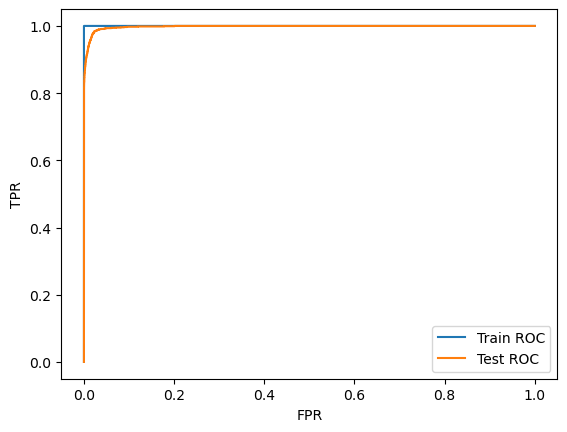

In [8]:
#checking for overfitting

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_train_pred = model.predict_proba(x_train)[:,1]
y_test_pred  = model.predict_proba(x_test)[:,1]

fpr_tr, tpr_tr, _ = roc_curve(y_train, y_train_pred)
fpr_te, tpr_te, _ = roc_curve(y_test,  y_test_pred)

plt.plot(fpr_tr, tpr_tr, label="Train ROC")
plt.plot(fpr_te, tpr_te, label="Test ROC")
plt.legend(); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.show()


In [ ]:
#demonstrates how to compare training and validation accuracy to detect overfitting:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification

# Generate synthetic binary classification dataset
X, y = make_classification(n_samples=1000, n_classes=2, random_state=42)

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_clf.fit(X_train, y_train)

# Predict on training and validation sets
train_preds = xgb_clf.predict(X_train)
val_preds = xgb_clf.predict(X_val)

# Calculate accuracy scores
train_accuracy = accuracy_score(y_train, train_preds)
val_accuracy = accuracy_score(y_val, val_preds)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Check for large difference between train and validation accuracy
if train_accuracy - val_accuracy > 0.1:
    print("Warning: The model may be overfitting!")

Training Accuracy: 1.0000
Validation Accuracy: 0.8850


In [10]:
import plotly
df = study.trials_dataframe()

best = study.best_trial

data = {
    "value": best.value,
    "params": best.params,
    "user_attrs": best.user_attrs,
    "system_attrs": best.system_attrs
}

objective(best)

NameError: name 'study' is not defined

In [ ]:

best_params = study.best_params
model = xgb.XGBClassifier(**best_params
)
model.fit(x_train, y_train)
pred = model.predict(x_test)
print(classification_report(y_test, pred))
evaluate_results(y_test, pred)
#https://www.geeksforgeeks.org/machine-learning/handling-imbalanced-data-for-classification/

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    935376
         1.0       0.75      0.45      0.56      1212

    accuracy                           1.00    936588
   macro avg       0.87      0.72      0.78    936588
weighted avg       1.00      1.00      1.00    936588

Classification results:
f1: 56.05%
roc: 72.43%
recall: 44.88%
precision: 74.62%


In [ ]:
y_score = model.predict_proba(x_test)[:, 1]


NameError: name 'model' is not defined

In [ ]:
import numpy as np

signal_scores = y_score[y_test == 1]
background_scores = y_score[y_test == 0]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.linspace(0, 1, 50)

plt.hist(signal_scores, bins=bins, histtype='step',
         density=True, linewidth=2, color='red', label='Signal')

plt.hist(background_scores, bins=bins, histtype='step',
         density=True, linewidth=2, color='blue', label='Background')

plt.xlabel("XGBoost score")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
